# Preparation

In [38]:
import os,sys,glob,copy
import numpy as np
import itertools

# matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# scipy
import scipy.signal
import scipy.constants as sconst
from scipy.optimize import curve_fit
from scipy import stats

# astropy
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS, utils
import astropy.units as u
from astropy import constants as aconst
from astropy.io.ascii import SExtractor
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.coordinates import SkyCoord, Angle
from astropy.cosmology import Planck18, z_at_value, FlatLambdaCDM

from astroquery.atomic import AtomicLineList

# regions
from regions import PixCoord, CircleSkyRegion, EllipseSkyRegion, EllipsePixelRegion, TextSkyRegion

# lmfit
from lmfit import Model

# Miscellaneous
from tqdm import tqdm_notebook as tqdm
import random

FlatLambdaCDM(H0=70 km / (Mpc s), Om0=0.3, Tcmb0=2.725 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=None)

## Wavelengths

In [2]:
w_4341 = 4341.692 * u.angstrom
w_4862 = 4862.69 * u.angstrom
w_4960 = 4960.295 * u.angstrom
w_5008 = 5008.240 * u.angstrom
w_6564 = 6564.61 * u.angstrom
w_6585 = 6585.27 * u.angstrom
w_6718 = 6718.294 * u.angstrom
w_6732 = 6732.673 * u.angstrom
w_9071 = 9071.1 * u.angstrom
w_9533 = 9533.2 * u.angstrom
w_10052 = 10052.123 * u.angstrom         # P-delta
w_10830 = 10833.306444 * u.angstrom      # HeI
w_10941 = 10941.082 * u.angstrom         # P-gamma
w_12821 = 12821.576 * u.angstrom         # P-beta
w_18756 = 18756.096 * u.angstrom         # P-alpha
w_19400 = 19400.00 * u.angstrom          # Br-delta

# Read catalog and i2d.fits

In [3]:
field = 'J0100'
if field == 'J0100':
    z_qso = 6.326 # J0100+2802
else:
    z_qso = np.nan
    

visit='1'
module='a'

vismod = visit+module
i2d_orig_dir = '../calibrated_img3_wfss'

i2d_dir = '../calibrated_img3_wfss_medSubt41'
se_dir = './results_calibrated_img3_wfss_medSubt41'

i2d_name = 'jw01243_nrc_img3_wfss_visit'+vismod+'_i2d.fits'
se_name = 'sex_jw01243_nrc_img3_wfss_visit'+vismod+'_i2d.fits'


In [4]:
pltdir = 'Plot_'+os.path.splitext(os.path.basename(se_name))[0]
print(pltdir)
if not os.path.isdir(pltdir):
    os.mkdir(pltdir)

Plot_sex_jw01243_nrc_img3_wfss_visit1a_i2d


In [5]:
outdir = 'Output_'+os.path.splitext(os.path.basename(se_name))[0]
print(outdir)
if not os.path.isdir(outdir):
    os.mkdir(outdir)

Output_sex_jw01243_nrc_img3_wfss_visit1a_i2d


In [6]:
i2d = fits.getdata(os.path.join(i2d_dir, i2d_name),1)
wcs = WCS(fits.getheader(os.path.join(i2d_dir, i2d_name),1)).celestial
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 15.06747219721938  28.0508237772287  
CRPIX : 1141.332749744267  1137.595999141579  
PC1_1 PC1_2  : -0.9999994307780586  -0.00106697870581809  
PC2_1 PC2_2  : -0.00106697870581809  0.9999994307780586  
CDELT : 1.74799277769329e-05  1.74799277769329e-05  
NAXIS : 2281  2273

In [7]:
kern = Gaussian2DKernel(1)
i2d_sm = convolve(i2d, kernel=kern)
print(i2d.shape, i2d_sm.shape)

(2273, 2281) (2273, 2281)


In [8]:
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 15.06747219721938  28.0508237772287  
CRPIX : 1141.332749744267  1137.595999141579  
PC1_1 PC1_2  : -0.9999994307780586  -0.00106697870581809  
PC2_1 PC2_2  : -0.00106697870581809  0.9999994307780586  
CDELT : 1.74799277769329e-05  1.74799277769329e-05  
NAXIS : 2281  2273

In [9]:
if os.path.isfile(os.path.join(i2d_orig_dir, i2d_name)):
    i2d_orig = fits.getdata(os.path.join(i2d_orig_dir, i2d_name))
else:
    print('No file')
    i2d_orig = i2d

In [10]:
#cat = fits.getdata(os.path.join(se_dir, se_name))
cat = Table.read(os.path.join(se_dir, se_name), format='fits')

In [11]:
cat

NUMBER,EXT_NUMBER,ALPHA_J2000,DELTA_J2000,FLUX_ISO,FLUXERR_ISO,MAG_ISO,MAGERR_ISO,FLUX_ISOCOR,FLUXERR_ISOCOR,MAG_ISOCOR,MAGERR_ISOCOR,FLUX_APER,FLUXERR_APER,MAG_APER,MAGERR_APER,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,FLUX_BEST,FLUXERR_BEST,MAG_BEST,MAGERR_BEST,KRON_RADIUS,PETRO_RADIUS,BACKGROUND,THRESHOLD,FLUX_MAX,ISOAREA_IMAGE,ISOAREAF_IMAGE,XMIN_IMAGE,YMIN_IMAGE,XMAX_IMAGE,YMAX_IMAGE,XPEAK_IMAGE,YPEAK_IMAGE,XPEAK_FOCAL,YPEAK_FOCAL,XPEAK_WORLD,YPEAK_WORLD,ALPHAPEAK_SKY,DELTAPEAK_SKY,ALPHAPEAK_J2000,DELTAPEAK_J2000,ALPHAPEAK_B1950,DELTAPEAK_B1950,X_IMAGE,Y_IMAGE,X_FOCAL,Y_FOCAL,X_WORLD,Y_WORLD,X_MAMA,Y_MAMA,ALPHA_SKY,DELTA_SKY,X2_IMAGE,Y2_IMAGE,XY_IMAGE,X2_WORLD,Y2_WORLD,XY_WORLD,CXX_IMAGE,CYY_IMAGE,CXY_IMAGE,CXX_WORLD,CYY_WORLD,CXY_WORLD,A_IMAGE,B_IMAGE,THETA_IMAGE,A_WORLD,B_WORLD,THETA_WORLD,THETA_SKY,THETA_J2000,ERRX2_IMAGE,ERRY2_IMAGE,ERRXY_IMAGE,ERRX2_WORLD,ERRY2_WORLD,ERRXY_WORLD,ERRCXX_IMAGE,ERRCYY_IMAGE,ERRCXY_IMAGE,ERRCXX_WORLD,ERRCYY_WORLD,ERRCXY_WORLD,ERRA_IMAGE,ERRB_IMAGE,ERRTHETA_IMAGE,ERRA_WORLD,ERRB_WORLD,ERRTHETA_WORLD,ERRTHETA_SKY,ERRTHETA_J2000,MU_THRESHOLD,MU_MAX,ISOAREA_WORLD,ISOAREAF_WORLD,ISO0,ISO1,ISO2,ISO3,ISO4,ISO5,ISO6,ISO7,FLAGS,FWHM_IMAGE,FWHM_WORLD,ELONGATION,ELLIPTICITY
,,,,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,ct,ct,mag,mag,,,ct,ct,ct,pix2,pix2,pix,pix,pix,pix,pix,pix,,,deg,deg,deg,deg,,,deg,deg,pix,pix,,,deg,deg,1 / m6,1 / m6,deg,deg,pix2,pix2,pix2,deg2,deg2,deg2,1 / pix2,1 / pix2,1 / pix2,1 / deg2,1 / deg2,1 / deg2,pix,pix,deg,deg,deg,deg,deg,deg,pix2,pix2,pix2,deg2,deg2,deg2,1 / pix2,1 / pix2,1 / pix2,1 / deg2,1 / deg2,1 / deg2,pix,pix,deg,deg,deg,deg,deg,deg,mag / arcsec2,mag / arcsec2,deg2,deg2,pix2,pix2,pix2,pix2,pix2,pix2,pix2,pix2,,pix,deg,,
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64
1,1,15.077007967371067,28.0312268092417,3.243354,0.0662812,25.20041499256318,0.0222,3.310033,0.06740309,25.178314992563177,0.0221,3.227531,0.06067412,25.205714992563177,0.0204,3.228286,0.0695811,25.205514992563177,0.0234,3.228286,0.0695811,25.205514992563177,0.0234,3.5,3.5,0.00055296,0.005814974,3.216662,6,44,658,13,664,19,661,16,-0.0083961817744,-0.01960541706,15.057960177,28.031218033,15.0579602,28.031218,15.077007911707367,28.031227001472395,14.3798248,27.7620436,660.9972,15.989,-0.0083962307008,-0.019605609686,15.057960121,28.031217841,28.0,15.1,15.0579601,28.0312178,1.6121907058,1.5946281916,0.025025553586,4.9260076871e-10,4.8723572673e-10,7.6468571305e-12,0.62042516,0.62725824,-0.019473484,0.00048723572,0.00049260078,-1.5293561e-05,1.277,1.256,35.33,2.231641e-05,2.195027e-05,35.33,54.67,54.67,2.5370027595e-05,2.4545185998e-05,9.7813732226e-07,7.75173345e-15,7.4997507996e-15,2.9888637007e-16,39477.25,40803.88,-3146.374,7.499751e-09,7.751733e-09,-5.977668e-10,0.0051,0.00489,33.57,8.916332e-08,8.544815e-08,33.57,56.43,56.43,0.0677,-7.2743,1.833287e-09,1.34441e-08,15,1,1,1,1,1,1,1,0,-19.21,-0.000335703,1.017,0.016
2,1,15.047408107122438,28.03112816522973,0.1382217,0.01400019,28.62651499256318,0.11,0.1557239,0.01553326,28.49701499256318,0.1083,0.1260655,0.01696198,28.72641499256318,0.1461,0.117292,0.02206476,28.804714992563177,0.2043,0.117292,0.02206476,28.80471499256317

In [12]:
cat_sky = SkyCoord(ra=cat['ALPHA_J2000'], dec=cat['DELTA_J2000'], unit='degree')

In [13]:
# wcs is 0-origin in python (pixel center)
wcs.pixel_to_world(0,0).to_string('hmsdms'), wcs.pixel_to_world(1,1).to_string('hmsdms'), wcs.pixel_to_world(999,999).to_string('hmsdms')

('01h00m21.6188s +28d01m51.5121s',
 '01h00m21.614s +28d01m51.575s',
 '01h00m16.8658s +28d02m54.3164s')

In [14]:
x,y=wcs.world_to_pixel(cat_sky)
#x-cat['X_IMAGE'], y-cat['Y_IMAGE']

In [15]:
i2d.shape

(2273, 2281)

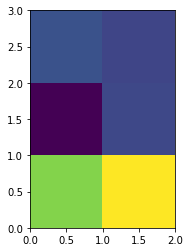

In [16]:
plt.imshow(np.random.rand(3,2),origin='lower',extent=[0,2,0,3])

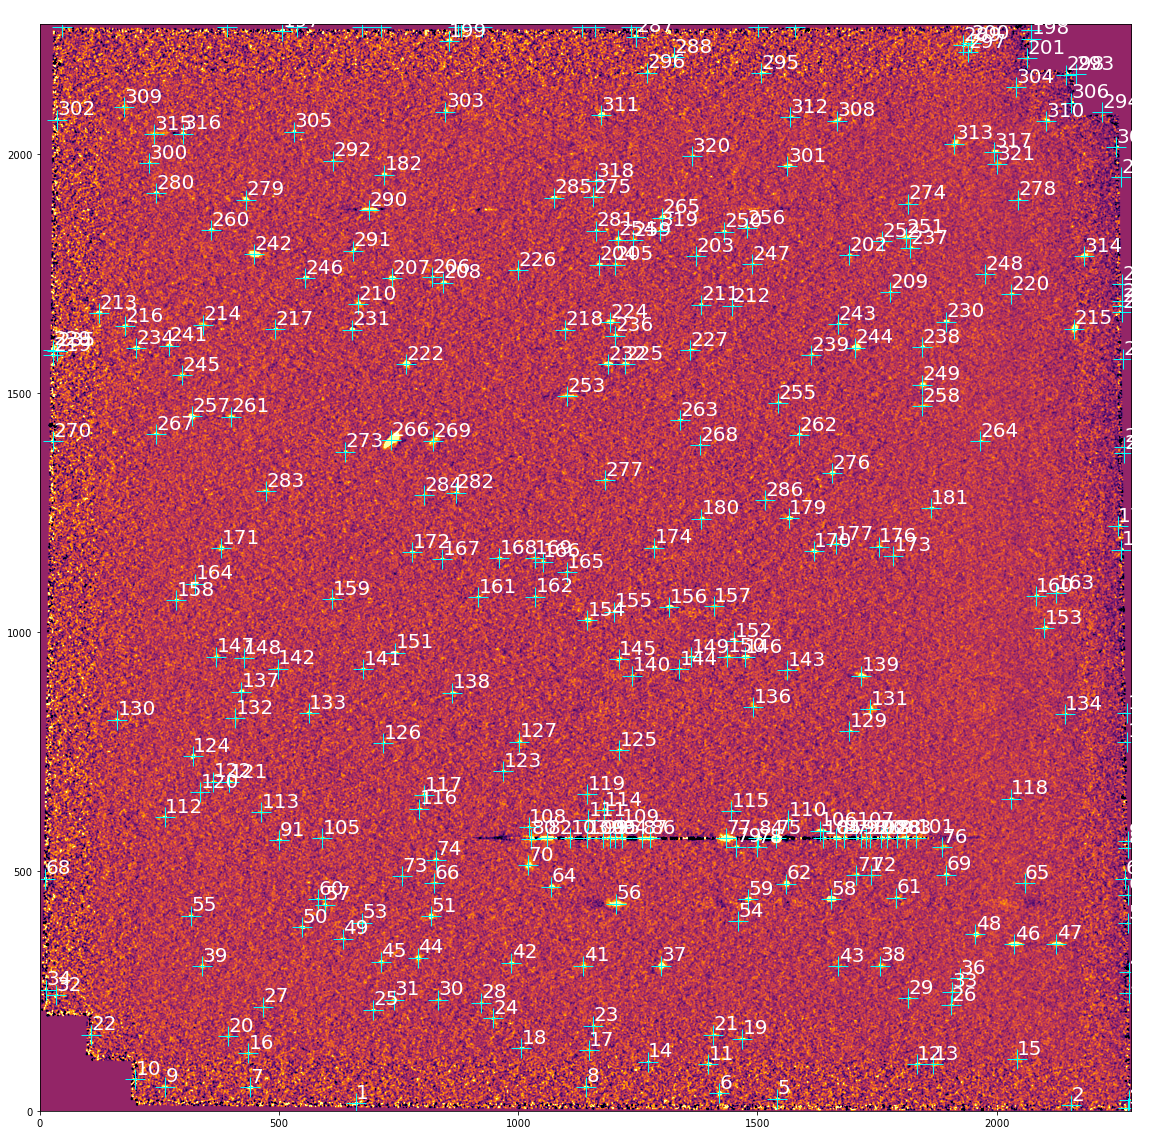

In [17]:
vmin, vmax = np.percentile(i2d, [5,95])
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

extent = [-0.5,i2d.shape[1]-0.5,-0.5,i2d.shape[0]-0.5]
ax.imshow(i2d_sm, vmin=vmin, vmax=vmax, 
          origin='lower', cmap='inferno',
          extent=extent)
ax.plot(cat['X_IMAGE']-1, cat['Y_IMAGE']-1, '+', ms=20, color='cyan', fillstyle='none')
for c in cat:
    plt.text(c['X_IMAGE'], c['Y_IMAGE']+10, c['NUMBER'], color='white', fontsize=20)

#ax.set_xlim(500,1000)
#ax.set_ylim(500,1000)
#ax.set_xlim(1300,1520)
#ax.set_ylim(1300,1520)

## Quasar spectrum

In [18]:
if field == 'J0100':
    if vismod == '1a':
        xlim_qso = [800,2000]
        ylim_qso = [560,580]
        x_4862_init, x_5008_init = 633, 740
    if vismod == '4b':
        xlim_qso = [200,1500]
        ylim_qso = [550,575]
        x_4862_init, x_5008_init = 547, 660

(560.0, 580.0)

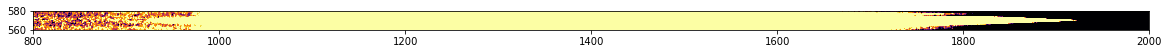

In [19]:
fig = plt.figure(figsize=(20,50))
ax = fig.add_subplot(111)

ax.imshow(i2d_orig, vmin=vmin, vmax=vmax, origin='lower', cmap='inferno', extent=extent)
ax.set_xlim(xlim_qso)
ax.set_ylim(ylim_qso)

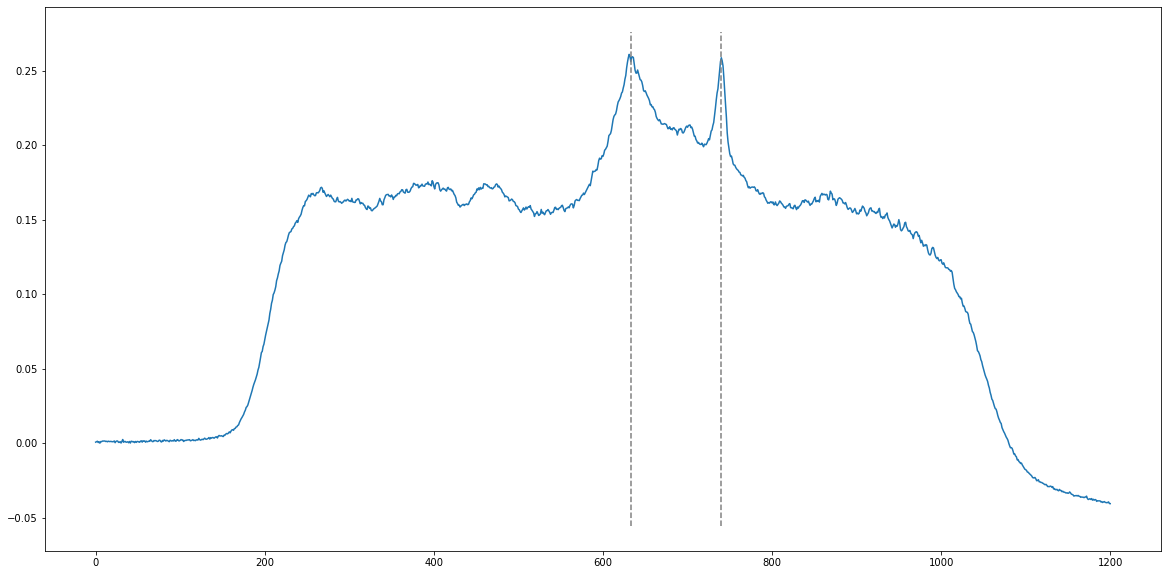

In [20]:


spec2d_qso = i2d_orig[ylim_qso[0]:ylim_qso[1]+1, xlim_qso[0]:xlim_qso[1]+1]
spec1d_qso = np.mean(spec2d_qso, axis=0)
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111)
ax.plot(spec1d_qso)
ylim = ax.get_ylim()
ax.plot(x_4862_init*np.ones(2), ylim, color='gray', ls='dashed')
ax.plot(x_5008_init*np.ones(2), ylim, color='gray', ls='dashed')



In [21]:
def mygauss(x, amp, mu, sigma):
    sigmasq = sigma**2
    return amp * np.exp( - (x - mu)**2 / (2 * sigmasq))

def determine_wpixscale(x, wpixscale, redshift, wobs0, w1, a1, s1, w2, a2, s2, cont):
    # Wavelength should be in angstrom
    w = wobs0 + np.arange(x.size) * wpixscale
    wo1 = w1 * (1.+redshift)
    so1 = s1 * (1.+redshift)
    wo2 = w2 * (1.+redshift)
    so2 = s2 * (1.+redshift)
    y = mygauss(w, a1, wo1, so1) + mygauss(w, a2, wo2, so2) + cont
    return y

In [22]:
mymodel = Model(determine_wpixscale)
params = mymodel.make_params(wpixscale = 10., 
                             redshift=z_qso, 
                             wobs0 = 29300., 
                             w1=w_4862.value, a1=0.05, s1=20.,
                             w2=w_5008.value, a2=0.05, s2=10.,
                             cont=0.20)
params['redshift'].vary = False 
params['w1'].vary = False 
params['w2'].vary = False 
print(params)

Parameters([('wpixscale', <Parameter 'wpixscale', value=10.0, bounds=[-inf:inf]>), ('redshift', <Parameter 'redshift', value=6.326 (fixed), bounds=[-inf:inf]>), ('wobs0', <Parameter 'wobs0', value=29300.0, bounds=[-inf:inf]>), ('w1', <Parameter 'w1', value=4862.69 (fixed), bounds=[-inf:inf]>), ('a1', <Parameter 'a1', value=0.05, bounds=[-inf:inf]>), ('s1', <Parameter 's1', value=20.0, bounds=[-inf:inf]>), ('w2', <Parameter 'w2', value=5008.24 (fixed), bounds=[-inf:inf]>), ('a2', <Parameter 'a2', value=0.05, bounds=[-inf:inf]>), ('s2', <Parameter 's2', value=10.0, bounds=[-inf:inf]>), ('cont', <Parameter 'cont', value=0.2, bounds=[-inf:inf]>)])


In [23]:
np.where(np.isfinite(spec1d_qso))

(array([   0,    1,    2, ..., 1198, 1199, 1200]),)

68
(1201,) (1201,) (1201,)


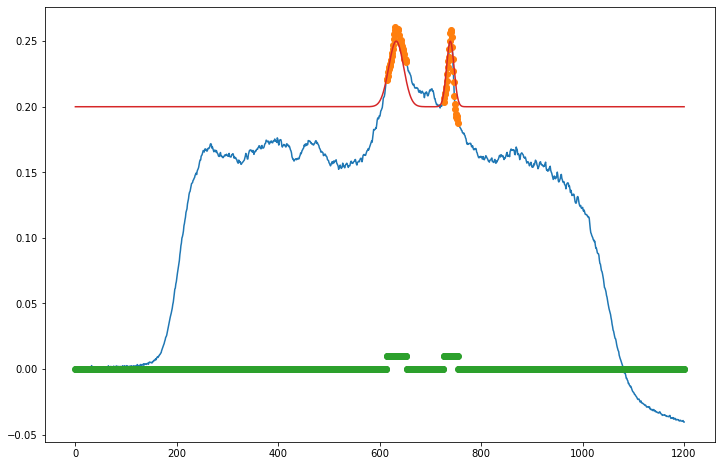

In [24]:
x = np.arange(spec1d_qso.size)*1.
weights = np.zeros(spec1d_qso.size)
idx_fit = np.where((np.isfinite(spec1d_qso))&((np.abs(x-x_4862_init)<20)|(np.abs(x-x_5008_init)<15)))[0]
print(idx_fit.size)
print(x.shape, weights.shape, spec1d_qso.shape)
weights[idx_fit]=1./0.01**2

plt.figure(figsize=(12,8))
plt.plot(x, spec1d_qso)
plt.plot(x[idx_fit], spec1d_qso[idx_fit], 'o')
plt.plot(x, weights*1e-6, 'o')
plt.plot(x, determine_wpixscale(x, 
                                params['wpixscale'],
                                params['redshift'],
                                params['wobs0'],
                                params['w1'],
                                params['a1'],
                                params['s1'],
                                params['w2'],
                                params['a2'],
                                params['s2'],
                                params['cont']))

In [25]:
result = mymodel.fit(spec1d_qso, params, x=x, weights=weights)
result

(0.15, 0.3)

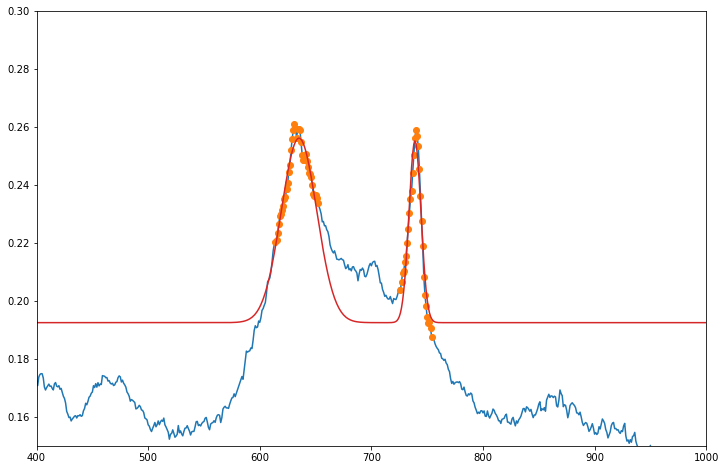

In [26]:
plt.figure(figsize=(12,8))
plt.plot(x, spec1d_qso)
plt.plot(x[idx_fit], spec1d_qso[idx_fit], 'o')
plt.plot(x, weights*1e-6, 'o')
plt.plot(x, determine_wpixscale(x, *result.values.values()))
plt.xlim(400,1000)
plt.ylim(0.15,0.3)

In [27]:
result.values

{'wpixscale': 10.263779851971966,
 'redshift': 6.326,
 'wobs0': 29104.868418850227,
 'w1': 4862.69,
 'a1': 0.06364366585916233,
 's1': 22.20809135546095,
 'w2': 5008.24,
 'a2': 0.06269702973019399,
 's2': 7.546616832831936,
 'cont': 0.19247586962484825}

# Find Hbeta+[OIII] and Halpha+[SII]



In [28]:
wpixscale = 10.25 * u.angstrom
zmin = 5.23
zmax = 7.0

wsep_4862_min, wsep_4862_max = (w_5008 - w_4862)*(zmin+1, zmax+1)
wsep_4960_min, wsep_4960_max = (w_5008 - w_4960)*(zmin+1, zmax+1)
xsep_4862_min, xsep_4862_max = wsep_4862_min/wpixscale * 0.9, wsep_4862_max/wpixscale * 1.1
xsep_4960_min, xsep_4960_max = wsep_4960_min/wpixscale * 0.9, wsep_4960_max/wpixscale * 1.1

print(wsep_4862_min, wsep_4862_max, xsep_4862_min, xsep_4862_max)
print(wsep_4960_min, wsep_4960_max, xsep_4960_min, xsep_4960_max)

906.7765000000012 Angstrom 1164.4000000000015 Angstrom 79.61940000000011 124.96000000000016
298.6973499999982 Angstrom 383.5599999999977 Angstrom 26.227084390243746 41.16253658536561


In [29]:
def pix_separation(w1, w2, z, wpixscale=10.25*u.angstrom):
    sep = (w2-w1)*(1+z)/wpixscale
    return sep

In [30]:
wpixscale = 10.25 * u.angstrom
zminl = 3.75
zmaxl = 5.10

wsep_6585_min, wsep_6585_max = (w_6585 - w_6564)*(zminl+1, zmaxl+1)
wsep_6718_min, wsep_6718_max = (w_6718 - w_6564)*(zminl+1, zmaxl+1)
wsep_6732_min, wsep_6732_max = (w_6732 - w_6564)*(zminl+1, zmaxl+1)
xsep_6585_min, xsep_6585_max = wsep_6585_min/wpixscale * 0.9, wsep_6585_max/wpixscale * 1.1
xsep_6718_min, xsep_6718_max = wsep_6718_min/wpixscale * 0.9, wsep_6718_max/wpixscale * 1.1
xsep_6732_min, xsep_6732_max = wsep_6732_min/wpixscale * 0.9, wsep_6732_max/wpixscale * 1.1

print(wsep_6585_min, wsep_6585_max, xsep_6585_min, xsep_6585_max)
print(wsep_6718_min, wsep_6718_max, xsep_6718_min, xsep_6718_max)
print(wsep_6732_min, wsep_6732_max, xsep_6732_min, xsep_6732_max)

98.13500000000363 Angstrom 126.02600000000466 Angstrom 8.616731707317392 13.524741463415134
729.9990000000009 Angstrom 937.4724000000011 Angstrom 64.09747317073179 100.6067941463416
798.2992500000005 Angstrom 1025.1843000000006 Angstrom 70.09456829268296 110.01977853658543


In [31]:
spec1d_arr=[]

if module=='a':
    sign=1
else:
    sign=-1
    
for i in np.arange(len(cat)):
#for i in [65]:
    #print(i)
    c = cat[i]
    x0, x1 = c['XPEAK_IMAGE']-1 + np.array([-150,150])
    
    y0n, y1n = c['YMIN_IMAGE'], c['YMAX_IMAGE']
    y0, y1 = y0n-10, y1n+10

    fig = plt.figure(figsize=(20,9))
    ax = fig.add_subplot(211)
    ax.imshow(i2d, origin='lower', vmin=vmin, vmax=vmax, cmap='gray', extent=extent)
    ax.set_xlim(x0,x1)
    ax.set_ylim(y0,y1)
    ax.set_title('Visit '+str(visit)+'  Module '+module+'   NUMBER '+str(c['NUMBER']))

    ax.plot(c['X_IMAGE']-1, c['Y_IMAGE']-1, '+', ms=20, color='lime')
    ax.plot((c['X_IMAGE']-sign*xsep_4862_min)+[0,0], [y0,y1], color='cyan')
    ax.plot((c['X_IMAGE']-sign*xsep_4862_max)+[0,0], [y0,y1], color='cyan')
    ax.plot((c['X_IMAGE']-sign*xsep_4960_min)+[0,0], [y0,y1], color='cyan')
    ax.plot((c['X_IMAGE']-sign*xsep_4960_max)+[0,0], [y0,y1], color='cyan')

    ax.plot((c['X_IMAGE']+sign*xsep_6585_min)+[0,0], [y0,y1], color='magenta')
    ax.plot((c['X_IMAGE']+sign*xsep_6585_max)+[0,0], [y0,y1], color='magenta')
    ax.plot((c['X_IMAGE']+sign*xsep_6718_min)+[0,0], [y0,y1], color='magenta')
    ax.plot((c['X_IMAGE']+sign*xsep_6718_max)+[0,0], [y0,y1], color='magenta')
    ax.plot((c['X_IMAGE']+sign*xsep_6732_min)+[0,0], [y0,y1], color='magenta')
    ax.plot((c['X_IMAGE']+sign*xsep_6732_max)+[0,0], [y0,y1], color='magenta')
    
    ax.plot(ax.get_xlim(), y0n-0.5+(0,0), color='lime')
    ax.plot(ax.get_xlim(), y1n-0.5+(0,0), color='lime')
    if module=='b':
        ax.invert_xaxis()
    
    
    
    ax = fig.add_subplot(212)
    x0_ = np.max([0,int(x0)])
    spec1d_tmp = np.nansum(i2d[y0n:y1n+1, x0_:int(x1)+1], axis=0)

    xaxis=x0_+np.arange(spec1d_tmp.size)
    spec1d_arr.append({'x':xaxis, 'y':spec1d_tmp})
    
    ax.step(xaxis, spec1d_tmp, where='mid')
    ylim = ax.get_ylim()
    
    ax.plot((c['X_IMAGE']-sign*xsep_4862_min)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot((c['X_IMAGE']-sign*xsep_4862_max)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot((c['X_IMAGE']-sign*xsep_4960_min)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot((c['X_IMAGE']-sign*xsep_4960_max)+[0,0], ylim, color='cyan', ls='dotted')
    
    ax.plot((c['X_IMAGE']+sign*xsep_6585_min)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot((c['X_IMAGE']+sign*xsep_6585_max)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot((c['X_IMAGE']+sign*xsep_6718_min)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot((c['X_IMAGE']+sign*xsep_6718_max)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot((c['X_IMAGE']+sign*xsep_6732_min)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot((c['X_IMAGE']+sign*xsep_6732_max)+[0,0], ylim, color='magenta', ls='dotted')

    tmp = np.where((cat['X_IMAGE']-1>=x0)&
                   (cat['X_IMAGE']-1<=x1)&
                   (cat['Y_IMAGE']-1>=y0)&
                   (cat['Y_IMAGE']-1<=y1))[0]
    for j in tmp:
        ax.plot(cat[j]['X_IMAGE']-1+[0,0], ylim, color='lime')
        ax.text(cat[j]['X_IMAGE']-1, ylim[0]+(ylim[1]-ylim[0])*0.05, cat[j]['NUMBER'])
    
    ax.set_xlim(x0,x1)
    ax.set_ylim(ylim)
    if module=='b':
        ax.invert_xaxis()
    fig.tight_layout()
    fig.savefig(os.path.join(pltdir, 'img_'+str(c['NUMBER']).zfill(4)+'.pdf'))#,bbox_inches='tight', pad_inches=0.1)
    plt.clf()
    plt.close()


In [32]:
import PyPDF2
pdfs = sorted(glob.glob(os.path.join(pltdir,"img_*.pdf")))
merger = PyPDF2.PdfFileMerger()
for p in pdfs:
    merger.append(p)

merger.write(os.path.join(pltdir, 'merged_img.pdf'))
merger.close()

In [33]:
def mytext(ax, x, y, text, rotation=45):
    xlim = ax.get_xlim()
    if x > xlim[0]+30 and x < xlim[1]-30:
        ax.text(x, y, text,rotation=rotation)
    
    
wr = np.array([3.1e4, 4.0e4])*u.angstrom
spec1d_arr=[]

if module=='a':
    sign=1
else:
    sign=-1
    
for i in np.arange(len(cat)):
#for i in [18]:
    #print(i)
    c = cat[i]
    x0, x1 = 0, i2d.shape[1]-1
    
    y0n, y1n = c['YMIN_IMAGE']-1, c['YMAX_IMAGE']-1
    y0, y1 = y0n-10, y1n+10

    fig = plt.figure(figsize=(30,9))
    ax = fig.add_subplot(311)
    ax.imshow(i2d, origin='lower', vmin=vmin, vmax=vmax, cmap='gray', extent=extent, aspect=3)
    ax.set_xlim(x0,x1)
    ax.set_ylim(y0,y1)
    ax.set_title('Visit '+str(visit)+'  Module '+module+'   NUMBER '+str(c['NUMBER']))
    ax.plot(ax.get_xlim(), y0n-0.5+(0,0), color='lime')
    ax.plot(ax.get_xlim(), y1n+0.5+(0,0), color='lime')
    ax.plot(c['X_IMAGE']-1, c['Y_IMAGE']-1, 'o', ms=30, color='lime', fillstyle='none')
    xlim = ax.get_xlim()
    if module=='b':
        ax.invert_xaxis()

        
    ### middle panel -------------------------------------------------
    x0_ = np.max([0,int(x0)])
    spec1d_tmp = np.nansum(i2d[y0n:y1n+1, x0_:int(x1)+1], axis=0)
    xaxis=x0_+np.arange(spec1d_tmp.size)
    spec1d_arr.append({'x':xaxis, 'y':spec1d_tmp})

    ax = fig.add_subplot(312)
    ylim = np.nanpercentile(spec1d_tmp, [5, 95])*[2,4]
    
    xcen = c['X_IMAGE']-1

    # if [OIII]5008
    ax.plot(xcen + sign*pix_separation(w_5008, w_4862, wr[0]/w_4862-1)+[0,0], ylim, color='cyan', ls='dotted', label='if [OIII]5008')
    ax.plot(xcen + sign*pix_separation(w_5008, w_4862, wr[1]/w_5008-1)+[0,0], ylim, color='cyan', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_5008, w_4960, wr[0]/w_4960-1)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_5008, w_4960, wr[1]/w_5008-1)+[0,0], ylim, color='cyan', ls='dashed')

    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_5008, w_4862, wr[1]/w_5008-1),
           ylim[1], r'  H$\beta$', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_5008, w_4960, wr[1]/w_5008-1),
           ylim[1], r'  [OIII]4960', rotation=45)

    # if Halpha
    ax.plot(xcen + sign*pix_separation(w_6564, w_6718, wr[0]/w_6564-1)+[0,0], ylim, color='magenta', ls='dotted', label='if H'+r'$\alpha$')
    ax.plot(xcen + sign*pix_separation(w_6564, w_6718, wr[1]/w_6718-1)+[0,0], ylim, color='magenta', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_6564, w_6732, wr[0]/w_6564-1)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_6564, w_6732, wr[1]/w_6732-1)+[0,0], ylim, color='magenta', ls='dashed')

    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_6564, w_6718, wr[1]/w_6718-1),
           ylim[1], r'  [SII]6718', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_6564, w_6732, wr[1]/w_6732-1),
           ylim[1], r'  [SII]6732', rotation=45)
    
    
    # if [SIII]9533    
    ax.plot(xcen + sign*pix_separation(w_9533, w_9071, wr[0]/w_9071-1)+[0,0], ylim, color='purple', ls='dotted', label='if [SIII]9533')
    ax.plot(xcen + sign*pix_separation(w_9533, w_9071, wr[1]/w_9533-1)+[0,0], ylim, color='purple', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10052, wr[0]/w_9533-1)+[0,0], ylim, color='purple', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10052, wr[1]/w_10052-1)+[0,0], ylim, color='purple', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10830, wr[0]/w_9533-1)+[0,0], ylim, color='purple', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10830, wr[1]/w_10830-1)+[0,0], ylim, color='purple', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10941, wr[0]/w_9533-1)+[0,0], ylim, color='purple', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_9533, w_10941, wr[1]/w_10941-1)+[0,0], ylim, color='purple', ls='dashed')

    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_9533, w_9071, wr[1]/w_9533-1),
           ylim[1], r'  [SIII]9071', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_9533, w_10052, wr[1]/w_10052-1),
           ylim[1], r'  P$\delta$', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_9533, w_10830, wr[1]/w_10830-1),
           ylim[1], r'  HeI 10830', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_9533, w_10941, wr[1]/w_10941-1),
           ylim[1], r'  P$\gamma$', rotation=45)
    
    ax.legend()
    ax.plot(c['X_IMAGE']-1+[0,0], ylim, color='lime', linewidth=5)
    tmp = np.where((cat['X_IMAGE']-1>=x0)&
                   (cat['X_IMAGE']-1<=x1)&
                   (cat['Y_IMAGE']-1>=y0n-2)&
                   (cat['Y_IMAGE']-1<=y1n+2))[0]
    for j in tmp:
        ax.plot(cat[j]['X_IMAGE']-1+[0,0], ylim, color='lime')
        ax.text(cat[j]['X_IMAGE']-1, ylim[0]+(ylim[1]-ylim[0])*0.05, cat[j]['NUMBER'])
    
    
    ax.step(xaxis, spec1d_tmp, where='mid', color='red')
    ax.set_xlim(x0,x1)
    ax.set_ylim(ylim)
    if module=='b':
        ax.invert_xaxis()

        
    
    ### Bottom panel -------------------------------------------------
    ax = fig.add_subplot(313)
    
    xcen = c['X_IMAGE']-1

    # if HeI 10830
    ax.plot(xcen + sign*pix_separation(w_10830, w_9071, wr[0]/w_9071-1)+[0,0], ylim, color='cyan', ls='dotted', label='if HeI 10830')
    ax.plot(xcen + sign*pix_separation(w_10830, w_9071, wr[1]/w_10830-1)+[0,0], ylim, color='cyan', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_10830, w_9533, wr[0]/w_9533-1)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_10830, w_9533, wr[1]/w_10830-1)+[0,0], ylim, color='cyan', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_10830, w_10052, wr[0]/w_10052-1)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_10830, w_10052, wr[1]/w_10830-1)+[0,0], ylim, color='cyan', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_10830, w_10941, wr[0]/w_10830-1)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_10830, w_10941, wr[1]/w_10941-1)+[0,0], ylim, color='cyan', ls='dashed')
    ax.plot(xcen + sign*pix_separation(w_10830, w_12821, wr[0]/w_10830-1)+[0,0], ylim, color='cyan', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_10830, w_12821, wr[1]/w_12821-1)+[0,0], ylim, color='cyan', ls='dashed')

    
    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_10830, w_9071, wr[1]/w_10830-1),
           ylim[1], r'  [SIII]9071', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_10830, w_9533, wr[1]/w_10830-1),
           ylim[1], r'  [SIII]9533', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_10830, w_10052, wr[1]/w_10830-1), 
           ylim[1], r'  P$\delta$', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_10830, w_10941, wr[1]/w_10941-1),
           ylim[1], r'  P$\gamma$', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_10830, w_12821, wr[1]/w_12821-1),
           ylim[1], r'  P$\beta$', rotation=45)

    
    # if Pachen beta
    ax.plot(xcen + sign*pix_separation(w_12821, w_10830, wr[0]/w_10830-1)+[0,0], ylim, color='magenta', ls='dotted', label='if P'+r'$\beta$')
    ax.plot(xcen + sign*pix_separation(w_12821, w_10830, wr[1]/w_12821-1)+[0,0], ylim, color='magenta', ls='dashed')    
    ax.plot(xcen + sign*pix_separation(w_12821, w_10941, wr[0]/w_10941-1)+[0,0], ylim, color='magenta', ls='dotted')
    ax.plot(xcen + sign*pix_separation(w_12821, w_10941, wr[1]/w_12821-1)+[0,0], ylim, color='magenta', ls='dashed')
    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_12821, w_10941, wr[1]/w_12821-1),
           ylim[1], r'  P$\gamma$', rotation=45)
    mytext(ax, xcen + sign*pix_separation(w_12821, w_10830, wr[1]/w_12821-1),
           ylim[1], r'  HeI 10830', rotation=45)
 

    # if Pachen alpha
    ax.plot(xcen + sign*pix_separation(w_18756, w_19400, wr[0]/w_18756-1)+[0,0], ylim, color='purple', ls='dotted', 
            label='if P'+r'$\alpha$')
    ax.plot(xcen + sign*pix_separation(w_18756, w_19400, wr[1]/w_19400-1)+[0,0], ylim, color='purple', ls='dashed')
    ax.set_xlim(xlim)
    mytext(ax, xcen + sign*pix_separation(w_18756, w_19400, wr[1]/w_19400-1),
           ylim[1], r'  Br-$\delta$', rotation=45)
    
    
    ax.legend()
    ax.plot(c['X_IMAGE']-1+[0,0], ylim, color='lime', linewidth=5)
    tmp = np.where((cat['X_IMAGE']-1>=x0)&
                   (cat['X_IMAGE']-1<=x1)&
                   (cat['Y_IMAGE']-1>=y0n-2)&
                   (cat['Y_IMAGE']-1<=y1n+2))[0]
    for j in tmp:
        ax.plot(cat[j]['X_IMAGE']-1+[0,0], ylim, color='lime')
        ax.text(cat[j]['X_IMAGE']-1, ylim[0]+(ylim[1]-ylim[0])*0.05, cat[j]['NUMBER'])
    
    ax.step(xaxis, spec1d_tmp, where='mid', color='red')
    ax.set_xlim(x0,x1)
    ax.set_ylim(ylim)
    if module=='b':
        ax.invert_xaxis()

    fig.tight_layout()
    fig.savefig(os.path.join(pltdir, 'fullimg_'+str(c['NUMBER']).zfill(4)+'.pdf'))#,bbox_inches='tight', pad_inches=0.1)
    plt.clf()
    plt.close()


In [34]:
import PyPDF2
pdfs = sorted(glob.glob(os.path.join(pltdir,"fullimg_*.pdf")))
merger = PyPDF2.PdfFileMerger()
for p in pdfs:
    merger.append(p)

merger.write(os.path.join(pltdir, 'merged_fullimg.pdf'))
merger.close()

In [35]:
def determine_redshift(x, redshift, wpixscale, wobs0, w1, a1, w2, a2, w3, a3, sigma):
    # Wavelength should be in angstrom
    w = wobs0 + np.arange(x.size) * wpixscale

    wo1 = w1 * (1.+redshift)
    so1 = s1 * (1.+redshift)
    wo2 = w2 * (1.+redshift)
    so2 = s2 * (1.+redshift)
    y = mygauss(w, a1, wo1, so1) + mygauss(w, a2, wo2, so2)
    return y

In [36]:
if field=='J0100':
    if vismod='1a':
        num_5008_cand = [146]

SyntaxError: invalid syntax (<ipython-input-36-30aa4d96d091>, line 2)